# K08_02 – SVM Iris mit Plots (Student)

## Lernziele
- SVMs auf dem Iris-Datensatz anwenden
- ausgewählte 2D-Merkmalsräume visualisieren
- Parameterwahl reflektieren
- gute Trennungen ohne unnötige Überanpassung diskutieren

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

## 1. Iris-Daten laden

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

## 2. Zwei 2D-Merkmalsräume untersuchen

Wir vergleichen:
- Sepal-Länge und Sepal-Breite
- Petal-Länge und Petal-Breite

In [3]:
X_sepal = X[:, :2]
X_petal = X[:, 2:]

## 3. Hilfsfunktion zum Trainieren und Plotten

In [4]:
def fit_and_plot_svm(X2, y, title, C=1.0, kernel="rbf", gamma="scale"):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(C=C, kernel=kernel, gamma=gamma))
    ])
    pipe.fit(X2, y)

    fig, ax = plt.subplots(figsize=(6, 4))
    DecisionBoundaryDisplay.from_estimator(
        pipe, X2, response_method="predict", alpha=0.25, ax=ax
    )
    ax.scatter(X2[:, 0], X2[:, 1], c=y, edgecolor="k", s=30)
    ax.set_title(title)
    plt.show()

    return pipe

## 4. Erste Modelle mit Standardparametern

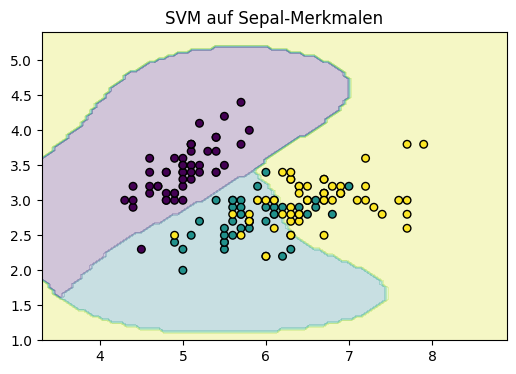

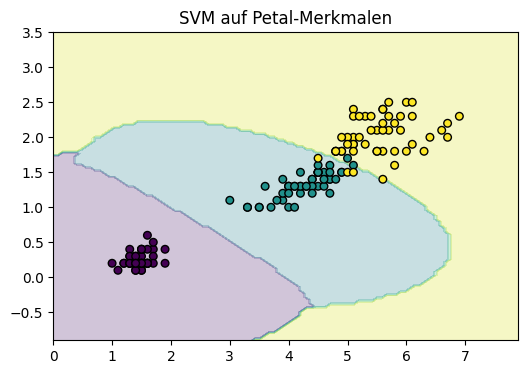

In [5]:
svm_sepal = fit_and_plot_svm(X_sepal, y, "SVM auf Sepal-Merkmalen", C=1.0, kernel="rbf")
svm_petal = fit_and_plot_svm(X_petal, y, "SVM auf Petal-Merkmalen", C=1.0, kernel="rbf")

## 5. Verschiedene Parameter auf den Petal-Merkmalen testen

In [6]:
param_grid = [
    (0.1, "rbf", "scale"),
    (1.0, "rbf", "scale"),
    (10.0, "rbf", "scale"),
    (1.0, "linear", "scale"),
]

results = []
for C, kernel, gamma in param_grid:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(C=C, kernel=kernel, gamma=gamma))
    ])
    pipe.fit(X_petal, y)
    acc = pipe.score(X_petal, y)
    results.append({
        "C": C,
        "kernel": kernel,
        "gamma": gamma,
        "Train-Accuracy": acc
    })

pd.DataFrame(results).round(4)

,C,kernel,gamma,Train-Accuracy
0,0.1,rbf,scale,0.9600
1,1.0,rbf,scale,0.9600
2,10.0,rbf,scale,0.9600
3,1.0,linear,scale,0.9533


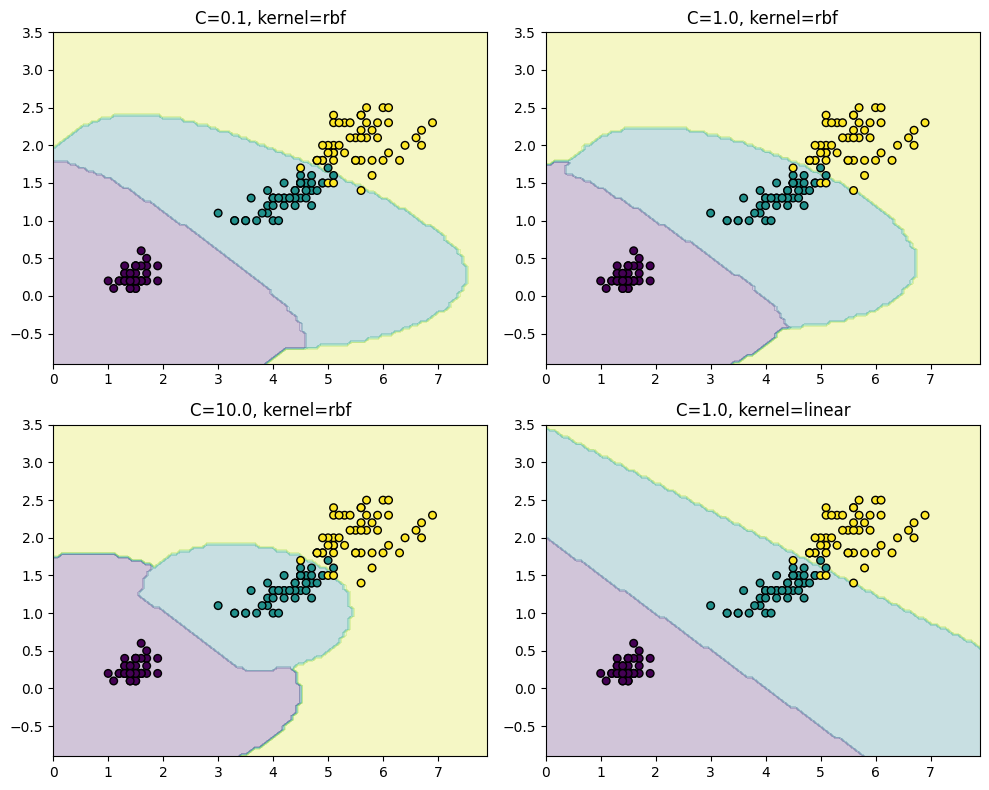

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (C, kernel, gamma) in zip(axes, param_grid):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(C=C, kernel=kernel, gamma=gamma))
    ])
    pipe.fit(X_petal, y)
    DecisionBoundaryDisplay.from_estimator(
        pipe, X_petal, response_method="predict", alpha=0.25, ax=ax
    )
    ax.scatter(X_petal[:, 0], X_petal[:, 1], c=y, edgecolor="k", s=30)
    ax.set_title(f"C={C}, kernel={kernel}")

plt.tight_layout()
plt.show()

## 6. Längere Übungsaufgabe

1. Vergleichen Sie Sepal- und Petal-Merkmale.
   - In welchem Raum ist die Trennung einfacher?
   - Warum?

2. Testen Sie verschiedene Werte von `C`.
   - Wann wirkt die Grenze zu starr?
   - Wann wird sie unnötig komplex?

3. Vergleichen Sie linearen und RBF-Kernel auf den Petal-Merkmalen.

4. Formulieren Sie eine begründete Empfehlung:
   - Welcher Parametersatz wirkt plausibel?
   - Welche Lösung liefert gute Trennung, ohne unnötig kompliziert zu wirken?

## 7. Fazit

- Auf Iris sind die Petal-Merkmale oft deutlich trennschärfer.
- SVMs können in 2D-Räumen sehr gut visualisiert und interpretiert werden.
- Die Parameterwahl sollte nicht nur auf perfekte Trainingsgüte, sondern auch auf Plausibilität zielen.